In [59]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [60]:
df = pd.read_csv("../../sample_data/placement_new.csv")

In [61]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package')

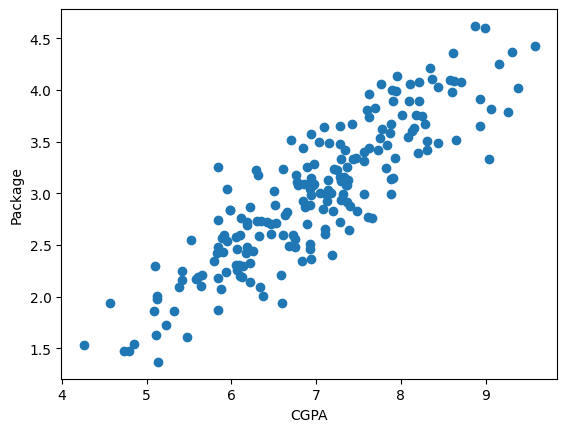

In [62]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package')
# plt.show()

In [63]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]


In [64]:
from sklearn.model_selection import train_test_split

In [65]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [66]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
y_pred


array([2.78031348, 3.13635249, 3.1995207 , 2.38981908, 3.52684689,
       3.76803461, 3.16506531, 2.54486832, 3.17655044, 3.4923915 ,
       1.90744364, 2.34962112, 3.6876387 , 2.75734322, 3.47516381,
       3.04447145, 2.32665086, 3.20526327, 2.17734418, 3.314372  ,
       2.45298729, 2.90090734, 3.32011456, 2.87219451, 3.33734226,
       2.19457187, 1.41932564, 2.7114027 , 3.18229301, 2.32665086,
       3.74506435, 2.95833298, 3.68189614, 2.97556068, 2.59080884,
       3.34882738, 2.47595755, 3.07318428, 4.17575671, 2.95833298])

In [67]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [68]:
 print('MAE',mean_absolute_error(y_test,y_pred))
#  in lpa

MAE 0.23150985393278373


In [69]:
print('MSE',mean_squared_error(y_test,y_pred))

MSE 0.08417638361329657


In [70]:
print('RMSE',np.sqrt(mean_squared_error(y_test,y_pred)))
# im lpa

RMSE 0.2901316659954521


In [71]:
print('r2score',r2_score(y_test,y_pred))
r2 =r2_score(y_test,y_pred)

r2score 0.7730984312051673


In [72]:
# adjusted r2 score 
x_test.shape

(40, 1)

In [73]:
adjr2 = 1-((1-r2)*(40-1)/(40-1-1))
adjr2

0.7671273372895138

In [81]:
# Create random feature
new_df1 = df.copy()
new_df1['random'] = np.random.random(len(df))

# Correct X and y
X = new_df1[['cgpa', 'random']]
y = new_df1['package']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

# Scores
r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R2:", r2)
print("Adjusted R2:", adj_r2)


R2: 0.7689951933269337
Adjusted R2: 0.7565084470202814


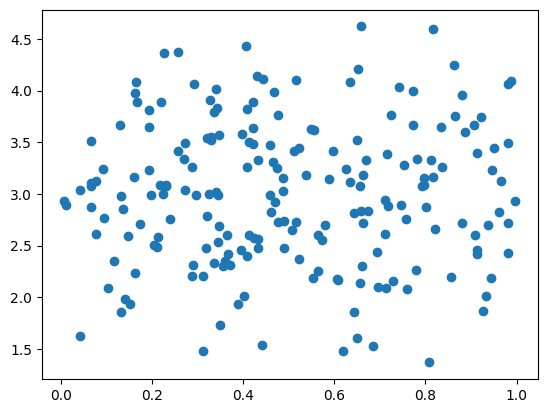

In [82]:
plt.scatter(new_df1['random'],new_df1['package'])

In [84]:
np.random.seed(42)

df_useful = df.copy()
df_useful['skill_score'] = (
    0.6 * df_useful['cgpa'] +
    0.4 * (df_useful['package'] / df_useful['package'].max()) +
    np.random.normal(0, 0.1, len(df_useful))
)


In [85]:
X = df_useful[['cgpa', 'skill_score']]
y = df_useful['package']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R2:", r2)
print("Adjusted R2:", adj_r2)


R2: 0.7972352187279933
Adjusted R2: 0.7862749602808579


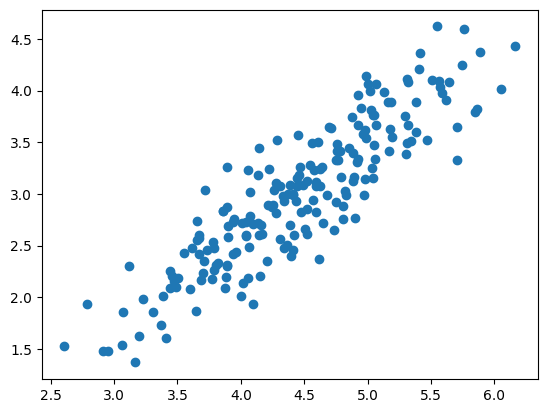

In [86]:
plt.scatter(df_useful['skill_score'],df_useful['package'])
